In [2]:
%load_ext autoreload
%autoreload 2

In [8]:
from predicting_loan.ml_logic.preprocessor import get_preprocessor
from predicting_loan.ml_logic.data import load_data
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, roc_auc_score
)
import numpy as np

In [1]:
from predicting_loan.ml_logic.data import load_and_prepare_data

/home/miguel/.pyenv/versions/3.12.9/envs/predicting-loan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'load_and_prepare_data' from 'predicting_loan.ml_logic.data' (/home/miguel/code/StephaneKEOU/predicting-loan/predicting_loan/ml_logic/data.py)

In [4]:

df = load_data("../raw_data/Loan_default.csv")

In [10]:
min_income = df['Income'].min()
max_income = df['Income'].max()

print(f"Income ranges from {min_income} to {max_income}")

Income ranges from 15000 to 149999


In [12]:
filtered_df = df[(df['Income'] >= min_income) & (df['Income'] <= 30_000)]
filtered_df[(df['Default']==1)]

/tmp/ipykernel_101725/1733987893.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df[(df['Default']==1)]


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
27,G8AIMX5E52,39,17633,167105,514,62,3,7.86,36,0.66,High School,Full-time,Single,Yes,Yes,Auto,Yes,1
84,42SRSHU039,25,24742,219541,719,73,3,15.21,12,0.60,PhD,Self-employed,Divorced,No,No,Auto,No,1
116,GXVEJUYTQ2,50,22773,174149,533,53,4,9.90,60,0.70,High School,Part-time,Divorced,Yes,No,Home,No,1
152,LRD1ETMYIL,32,29815,130015,528,1,4,21.53,12,0.48,PhD,Self-employed,Single,Yes,No,Home,No,1
170,PY0C08S9G2,46,15192,152778,734,115,2,22.42,60,0.47,PhD,Part-time,Married,Yes,No,Auto,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254970,OXJ00LKU3V,22,17785,236995,529,84,2,24.32,24,0.86,Bachelor's,Part-time,Divorced,No,No,Other,No,1
254991,I5JFY17JHU,33,24599,126673,667,31,4,22.90,12,0.88,Master's,Full-time,Divorced,Yes,Yes,Home,No,1
255029,XL7DN8X7AT,24,19642,121526,708,0,3,20.40,60,0.20,Bachelor's,Part-time,Single,No,No,Auto,Yes,1
255078,QSDL3CQ67K,39,25586,91483,301,84,3,20.42,36,0.47,Master's,Full-time,Single,No,No,Home,No,1


In [6]:
df.head(50).to_csv("50_data_sample.csv", index=False)

In [9]:
values, counts = np.unique(y, return_counts=True)
values, counts, counts / counts.sum()

NameError: name 'y' is not defined

In [4]:
features = ['Age', 'Income', 'LoanAmount', 'InterestRate', "MonthsEmployed", "EmploymentType"]

X = df[features]
y = df["Default"]

X.head()

,Age,Income,LoanAmount,InterestRate,MonthsEmployed,EmploymentType
0,56,85994,50587,15.23,80,Full-time
1,69,50432,124440,4.81,15,Full-time
2,46,84208,129188,21.17,26,Unemployed
3,32,31713,44799,7.07,0,Full-time
4,60,20437,9139,6.51,8,Unemployed


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [6]:
preprocessor = preprocess_data(X)

In [7]:
preprocessor

,transformers,"[('robust_num', ...), ('standard_num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [8]:
results = {}
roc_data = {}

model = LogisticRegression(max_iter=1000, class_weight="balanced")

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# FIT MODEL
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

# METRICS
results["LogisticRegression"] = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "y_pred": y_pred,
}

roc_data["LogisticRegression"] = (y_test, y_proba)

In [ ]:
results

{'LogisticRegression': {'accuracy': 0.6660870654949324,
  'f1': 0.3257417599797558,
  'recall': 0.6945905841089977,
  'precision': 0.21275980331391264,
  'roc_auc': 0.7424633427708487,
  'y_pred': array([1, 0, 0, ..., 0, 1, 0])}}

In [11]:
with open("../predicting_loan/models/logistic_model.pkl", "wb") as file:
    pickle.dump(pipe, file)

In [20]:
X_test.head(5)

,Age,Income,LoanAmount,InterestRate,MonthsEmployed,EmploymentType
131834,30,38632,216226,11.76,99,Unemployed
228947,23,135644,17941,14.20,12,Full-time
60842,45,146036,99962,16.99,30,Unemployed
80381,28,119725,223883,18.64,21,Unemployed
56260,50,38772,144422,22.92,108,Self-employed


In [30]:
X['EmploymentType'].unique()

array(['Full-time', 'Unemployed', 'Self-employed', 'Part-time'],
      dtype=object)

In [21]:
y_test.head(5)

131834    0
228947    1
60842     0
80381     1
56260     0
Name: Default, dtype: int64

In [23]:
pred = pipe.predict(X_test.head(5))
pred

array([1, 0, 0, 1, 1])

In [25]:
proba = pipe.predict_proba(X_test.head(5))
proba

array([[0.35122817, 0.64877183],
       [0.52484155, 0.47515845],
       [0.56085396, 0.43914604],
       [0.21323493, 0.78676507],
       [0.489536  , 0.510464  ]])

In [26]:
with open('../predicting_loan/models/logistic_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [28]:
loaded_model.predict(X_test.head(5))

array([1, 0, 0, 1, 1])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=42, stratify=y
)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((191510, 28), (63837, 28), (191510,), (63837,))

In [11]:
reg_l1 = regularizers.L1(0.01)
reg_l2 = regularizers.L2(0.01)
reg_l1_l2 = regularizers.l1_l2(l1=0.005, l2=0.0005)

E0000 00:00:1763745584.873531   42972 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763745584.880842   42972 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [42]:
def initialize_model():
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(layers.Dense(32, activation='relu', kernel_regularizer=reg_l1))
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           AUC(name='roc_auc')])
    return model

model = initialize_model()

In [32]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
parameters = model.count_params()
print(f'The model has {parameters} parameters.')

The model has 2017 parameters.


In [34]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,-0.034751,0.347735,0.516667,0.900700,0.054975,0.914230,0.908503,2.0,3.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.593366,0.901627,-0.216667,1.434381,-0.284854,-1.559991,0.128999,3.0,3.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.272341,0.682461,-0.083333,-0.700343,-0.184164,-1.255611,-1.256785,2.0,3.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.956368,-0.689113,-0.766667,1.634511,-1.461669,-0.877395,-0.000918,0.0,3.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.474823,-0.073395,0.816667,-0.033242,0.394803,0.941353,-0.693811,0.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, roc_auc_score
)
from keras.callbacks import EarlyStopping

In [43]:
es = EarlyStopping(patience=20,
                   monitor='val_loss',
                   restore_best_weights=True)

# FIT MODEL
model.fit(X_train,
          y_train,
          epochs=8,
          batch_size=32,
          verbose=1,
          validation_split=0.2,
          callbacks=[es])
results = {}

# PREDICTIONS PROBA
y_proba = model.predict(X_test).ravel()
# CLASS PREDICTIONS
y_pred = (y_proba >= 0.188).astype(int)

# METRICS
results['Neural Network'] = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba)
}

Epoch 1/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8828 - loss: 0.3823 - roc_auc: 0.7220 - val_accuracy: 0.8860 - val_loss: 0.3313 - val_roc_auc: 0.7375
Epoch 2/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8835 - loss: 0.3298 - roc_auc: 0.7368 - val_accuracy: 0.8875 - val_loss: 0.3223 - val_roc_auc: 0.7436
Epoch 3/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8841 - loss: 0.3278 - roc_auc: 0.7383 - val_accuracy: 0.8878 - val_loss: 0.3214 - val_roc_auc: 0.7414
Epoch 4/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8838 - loss: 0.3270 - roc_auc: 0.7388 - val_accuracy: 0.8876 - val_loss: 0.3205 - val_roc_auc: 0.7421
Epoch 5/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8841 - loss: 0.3269 - roc_auc: 0.7381 - val_accuracy: 0.8869 - val_loss: 0.3202 - val_roc_auc: 0.7421
Epoch 6/8
4788/4788 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.8843 - loss: 0.3268 - roc_auc: 0.7383 - val_accuracy: 0.8871 - val_loss: 0.3216 - val_ro

In [44]:
history = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {history[0]}, Test Accuracy: {history[1]}')

Test Loss: 0.32106393575668335, Test Accuracy: 0.8851919770240784


In [45]:
results['Neural Network']

{'accuracy': 0.817127997869574,
 'f1': 0.3596269884805266,
 'recall': 0.4421961419128558,
 'precision': 0.3030415087362485,
 'roc_auc': 0.7513704018364051}

In [20]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame(y_pred, columns=['y_pred'])
results_df.head()

1995/1995 ━━━━━━━━━━━━━━━━━━━━ 2s 822us/step


,y_pred
0,0.115796
1,0.115796
2,0.115796
3,0.115796
4,0.115796


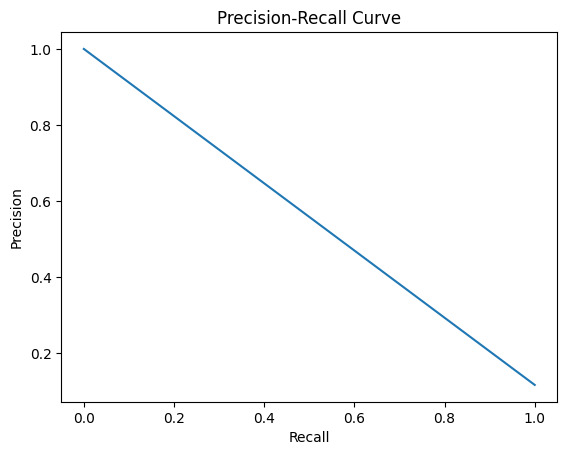

In [21]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# precision/recall have length = len(thresholds) + 1
# We drop the last point (it has no corresponding threshold)
precision = precision[:-1]
recall = recall[:-1]

f1_scores = 2 * (precision * recall) / (precision + recall)

# Replace NaNs (from 0/0) with 0 so they don't win argmax
f1_scores = np.nan_to_num(f1_scores, nan=0.0)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.11579577
Best F1: 0.2080842105263158


In [23]:
y_pred_opt = (y_proba >= best_threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall   :", recall_score(y_test, y_pred_opt))
print("F1       :", f1_score(y_test, y_pred_opt))

Precision: 0.1161238780017858
Recall   : 1.0
F1       : 0.2080842105263158


===============================

In [8]:
X, y = load_and_prepare_data()

X_sample = X.head(5)
X_sample

Local file not found at raw_data/Loan_default.csv. Pulling dataset from Kaggle...
Using Kaggle dataset file: /home/miguel/.cache/kagglehub/datasets/nikhil1e9/loan-default/versions/2/Loan_default.csv


,Age,Income,LoanAmount,MonthsEmployed,InterestRate,EmploymentType
0,56,85994,50587,80,15.23,Full-time
1,69,50432,124440,15,4.81,Full-time
2,46,84208,129188,26,21.17,Unemployed
3,32,31713,44799,0,7.07,Full-time
4,60,20437,9139,8,6.51,Unemployed


In [7]:
from predicting_loan.api_file import batch_predict
from predicting_loan.frontend.core.model_client import convert_to_api_format

In [9]:
FIELD_MAPPING = {
    "MonthsEmployed": "months_employed",
    "Age": "age",
    "Income": "income",
    "LoanAmount": "loan_amount",
    "InterestRate": "interest_rate",
    "EmploymentType": "employment_type",
}

In [58]:
X_sample.columns = [FIELD_MAPPING[col] for col in X.columns]
X_sample

X_sample.to_csv("5 applicants.csv", index=False)

In [ ]:
# transform DataFrame to JSON

json_data = []

for index, row in X_sample.iterrows():

    json_data.append(row.to_dict())

json_data


[{'age': 56,
  'income': 85994,
  'loan_amount': 50587,
  'months_employed': 80,
  'interest_rate': 15.23,
  'employment_type': 'Full-time'},
 {'age': 69,
  'income': 50432,
  'loan_amount': 124440,
  'months_employed': 15,
  'interest_rate': 4.81,
  'employment_type': 'Full-time'},
 {'age': 46,
  'income': 84208,
  'loan_amount': 129188,
  'months_employed': 26,
  'interest_rate': 21.17,
  'employment_type': 'Unemployed'},
 {'age': 32,
  'income': 31713,
  'loan_amount': 44799,
  'months_employed': 0,
  'interest_rate': 7.07,
  'employment_type': 'Full-time'},
 {'age': 60,
  'income': 20437,
  'loan_amount': 9139,
  'months_employed': 8,
  'interest_rate': 6.51,
  'employment_type': 'Unemployed'}]

In [59]:
json_data = [
  {
    "loan_amount": 5000,
    "months_employed": 24,
    "age": 35,
    "income": 60000,
    "interest_rate": 5.5,
    "employment_type": "Full-time"
  },
{
    "loan_amount": 5000,
    "months_employed": 24,
    "age": 35,
    "income": 40000,
    "interest_rate": 10.5,
    "employment_type": "Part-time"
  }
]

In [60]:
batch_predict(json_data)

2025-11-30 20:32:45,869 | loan_api | INFO | Received batch request with 2 records


[{'loan_amount': 5000, 'months_employed': 24, 'age': 35, 'income': 60000, 'interest_rate': 5.5, 'employment_type': 'Full-time'}, {'loan_amount': 5000, 'months_employed': 24, 'age': 35, 'income': 40000, 'interest_rate': 10.5, 'employment_type': 'Part-time'}]
[{'LoanAmount': 5000, 'MonthsEmployed': 24, 'Age': 35, 'Income': 60000, 'InterestRate': 5.5, 'EmploymentType': 'Full-time'}, {'LoanAmount': 5000, 'MonthsEmployed': 24, 'Age': 35, 'Income': 40000, 'InterestRate': 10.5, 'EmploymentType': 'Part-time'}]


{'prediction': array([0, 0]), 'probability': array([0.05889926, 0.12148622])}